In [1]:
#Importing Required Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Import modules from sklearn library
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, precision_score, recall_score, classification_report

#Import Harmless Warnings
import warnings
warnings.filterwarnings('ignore')

#Notebook Formatting
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
#Importing data
data = pd.read_csv('bank.csv')

In [3]:
#Sample data
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
#Data Shape
data.shape

(11162, 17)

In [5]:
pd.DataFrame({'Missing Values' : round(data.isnull().mean(), 2), 'Data Type' : data.dtypes})

,Missing Values,Data Type
age,0.0,int64
job,0.0,object
marital,0.0,object
education,0.0,object
default,0.0,object
balance,0.0,int64
housing,0.0,object
loan,0.0,object
contact,0.0,object
day,0.0,int64


In [6]:
# Unique value check
for cols in data.columns:
    if data[cols].dtype == 'O':
        print(cols, ':', data[cols].nunique())

job : 12
marital : 3
education : 4
default : 2
housing : 2
loan : 2
contact : 3
month : 12
poutcome : 4
deposit : 2


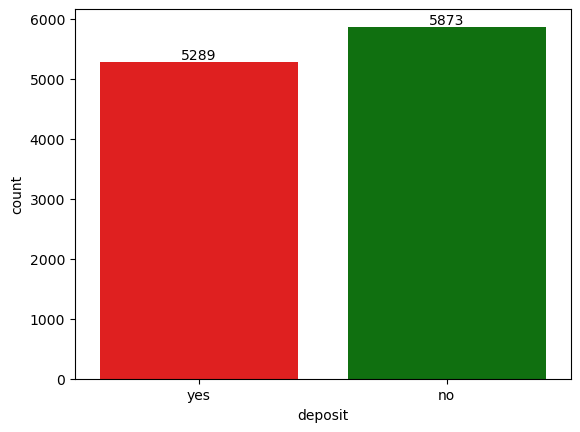

deposit
no     52.62
yes    47.38
Name: proportion, dtype: float64

In [7]:
#Target Column analysis
data['deposit'].value_counts()
ax = sns.countplot(data =  data, x= data['deposit'], palette = {'red', 'green'})
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

#Proportion check
round(data['deposit'].value_counts(normalize = True)*100, 2)

# Preparing the data for ML Models

## Dependency split

In [8]:
#Dependency split
x = data.drop(['deposit'], axis = 1)
y = data[['deposit']]
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)
print(f'Dimension of Train Colum: {x_train.shape, y_train.shape}')
print(f'Dimension of Test Colum: {x_test.shape, y_test.shape}')

Dimension of Train Colum: ((7813, 16), (7813, 1))
Dimension of Test Colum: ((3349, 16), (3349, 1))


## Label Encoding

In [9]:
#Label encoding

#Using categorical columns for encoding
cat_cols = [cols for cols in x_train.columns if x_train[cols].dtype == 'O']

#Label encoder
encoders = {}

#Apply label encoding on x_train columns
for col in cat_cols:
    encoders[col] = LabelEncoder()
    x_train[col] = encoders[col].fit_transform(x_train[col])

#Apply label encoding on x_test columns
for col in cat_cols:
    x_test[col] = encoders[col].transform(x_test[col])

## Building Decision Tree Model

In [10]:
# Buliding a simple decision tree model with random parameters
model = DecisionTreeClassifier(max_depth = 7, random_state = 42)
model.fit(x_train, y_train)
train_score = model.score(x_train, y_train)
print('Training Score:', round((train_score)*100,2), '%') 

Training Score: 83.69 %


In [11]:
#Test prediction
y_pred = model.predict(x_test)

#Accuracy score
test_score = accuracy_score(y_test, y_pred)
print('Testing Score:', round((test_score)*100,2), '%')
print('Recall Score:', round((recall_score(y_test, y_pred, pos_label = 'yes'))*100,2), '%')
print('Precision Score:', round((precision_score(y_test, y_pred, pos_label = 'yes'))*100,2), '%')

Testing Score: 81.55 %
Recall Score: 76.23 %
Precision Score: 83.85 %


              precision    recall  f1-score   support

          no       0.80      0.86      0.83      1742
         yes       0.84      0.76      0.80      1607

    accuracy                           0.82      3349
   macro avg       0.82      0.81      0.81      3349
weighted avg       0.82      0.82      0.81      3349



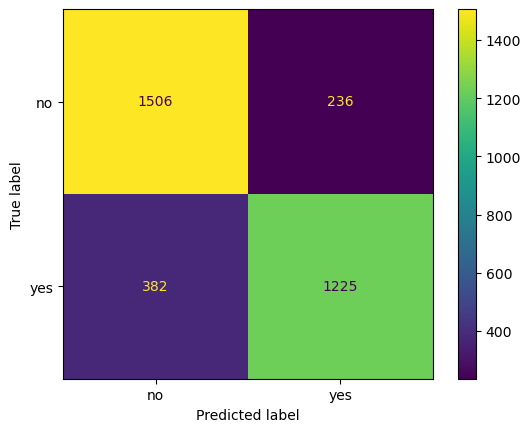

In [12]:
# Confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print(classification_report(y_test, y_pred))

In [13]:
#Using loop to determine, which model is best based on max_depth parameter tuning:

results = []

for depth in range(6, 13):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    results.append({
        'max_depth': depth,
        'train_score': round(model.score(x_train, y_train)*100, 2),
        'test_score': round(accuracy_score(y_test, y_pred)*100, 2),
        'recall': round(recall_score(y_test, y_pred, pos_label='yes')*100, 2),
        'precision': round(precision_score(y_test, y_pred, pos_label='yes')*100, 2)
    })

# Display results
for r in results:
    print(f"max_depth {r['max_depth']}: Train {r['train_score']}%, Test {r['test_score']}%, Recall {r['recall']}%, Precision {r['precision']}%")

max_depth 6: Train 82.29%, Test 80.62%, Recall 81.83%, Precision 78.65%
max_depth 7: Train 83.69%, Test 81.55%, Recall 76.23%, Precision 83.85%
max_depth 8: Train 85.15%, Test 81.31%, Recall 79.84%, Precision 80.95%
max_depth 9: Train 87.16%, Test 80.68%, Recall 79.59%, Precision 80.04%
max_depth 10: Train 88.76%, Test 80.77%, Recall 77.78%, Precision 81.33%
max_depth 11: Train 90.82%, Test 81.07%, Recall 79.59%, Precision 80.69%
max_depth 12: Train 92.18%, Test 80.41%, Recall 79.03%, Precision 79.92%


In [14]:
# Parameter for the grid
params = {'max_depth': list(range(6,13)),
          'min_samples_split': list(range(2,9,2)),
          'min_samples_leaf': list(range(1,5))}

# estimator - classifier
dt = DecisionTreeClassifier(random_state = 42)

# setup the grid search
grid_search = GridSearchCV(estimator = dt,
                           param_grid = params,
                           cv = 5,
                           n_jobs = -1,
                           verbose = 4)

# fit the gridsearch model to the data
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 112 candidates, totalling 560 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [6, 7, 8, 9, 10, 11, 12],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 4, 6, 8]},
             verbose=4)

In [15]:
# Display the best param and the score
print('Best Parameters from the grid search are:', grid_search.best_params_)
print('Score for the best params:', round(grid_search.best_score_*100, 2), '%')

Best Parameters from the grid search are: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 8}
Score for the best params: 81.03 %


In [16]:
# Building the final model with best parameters
best_params = grid_search.best_params_
final_model = DecisionTreeClassifier(**best_params, random_state = 42)

# Fit the data onto the model
final_model.fit(x_train, y_train)
print('Training Score:', round(final_model.score(x_train, y_train)*100, 2), '%')

Training Score: 84.95 %


Classification Report:
               precision    recall  f1-score   support

          no       0.82      0.82      0.82      1742
         yes       0.81      0.80      0.80      1607

    accuracy                           0.81      3349
   macro avg       0.81      0.81      0.81      3349
weighted avg       0.81      0.81      0.81      3349
 %


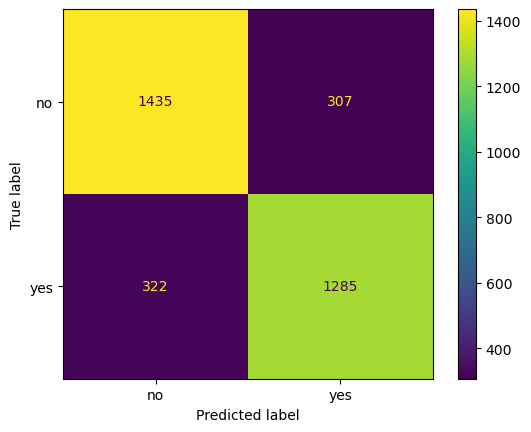

In [17]:
# Test prediction
y_pred_final = final_model.predict(x_test)

# Detailed metrics
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
print('Classification Report:\n', classification_report(y_test, y_pred_final), '%')

In [18]:
# Parameter for the grid using entropy
params = {'max_depth': list(range(6,13)),
          'min_samples_split': list(range(2,9,2)),
          'min_samples_leaf': list(range(1,5)),
          'criterion' : ['gini', 'entropy']}

# estimator - classifier
dt = DecisionTreeClassifier(random_state = 42)

# setup the grid search
grid_search = GridSearchCV(estimator = dt,
                           param_grid = params,
                           cv = 5,
                           n_jobs = -1,
                           verbose = 4)

# fit the gridsearch model to the data
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 224 candidates, totalling 1120 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [6, 7, 8, 9, 10, 11, 12],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 4, 6, 8]},
             verbose=4)

In [19]:
# Building the final model with best parameters
best_params = grid_search.best_params_
final_model = DecisionTreeClassifier(**best_params, random_state = 42)

# Fit the data onto the model
final_model.fit(x_train, y_train)
print('Training Score:', round(final_model.score(x_train, y_train)*100, 2), '%')

Training Score: 84.68 %


Classification Report:
               precision    recall  f1-score   support

          no       0.82      0.82      0.82      1742
         yes       0.81      0.81      0.81      1607

    accuracy                           0.82      3349
   macro avg       0.81      0.81      0.81      3349
weighted avg       0.82      0.82      0.82      3349
 %


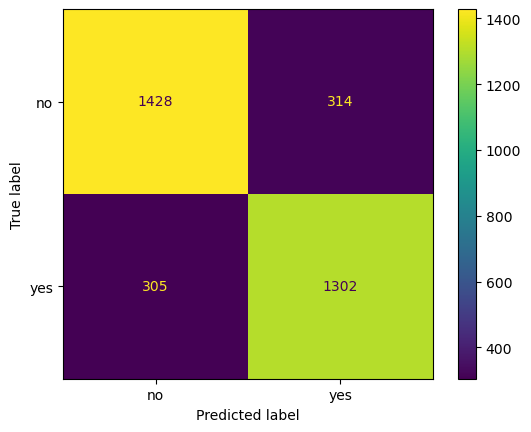

In [20]:
# Test prediction
y_pred_final = final_model.predict(x_test)

# Detailed metrics
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
print('Classification Report:\n', classification_report(y_test, y_pred_final), '%')

In [21]:
# Parameter for the grid using log_loss
params = {'max_depth': list(range(6,13)),
          'min_samples_split': list(range(2,9,2)),
          'min_samples_leaf': list(range(1,5)),
          'criterion' : ['gini', 'log_loss']}

# estimator - classifier
dt = DecisionTreeClassifier(random_state = 42)

# setup the grid search
grid_search = GridSearchCV(estimator = dt,
                           param_grid = params,
                           cv = 5,
                           n_jobs = -1,
                           verbose = 4)

# fit the gridsearch model to the data
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 224 candidates, totalling 1120 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'log_loss'],
                         'max_depth': [6, 7, 8, 9, 10, 11, 12],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 4, 6, 8]},
             verbose=4)

In [22]:
# Building the final model with best parameters
best_params = grid_search.best_params_
final_model = DecisionTreeClassifier(**best_params, random_state = 42)

# Fit the data onto the model
final_model.fit(x_train, y_train)
print('Training Score:', round(final_model.score(x_train, y_train)*100, 2), '%')

Training Score: 84.68 %


Classification Report:
               precision    recall  f1-score   support

          no       0.82      0.82      0.82      1742
         yes       0.81      0.81      0.81      1607

    accuracy                           0.82      3349
   macro avg       0.81      0.81      0.81      3349
weighted avg       0.82      0.82      0.82      3349
 %


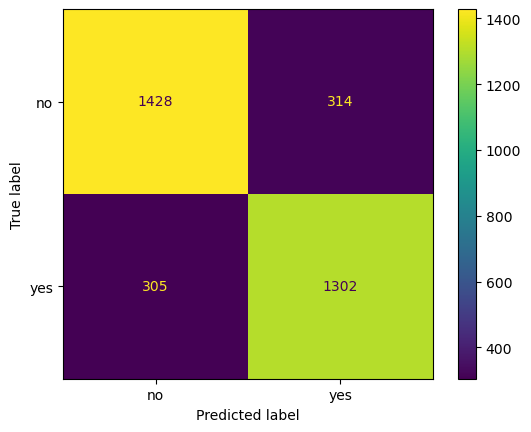

In [23]:
# Test prediction
y_pred_final = final_model.predict(x_test)

# Detailed metrics
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
print('Classification Report:\n', classification_report(y_test, y_pred_final), '%')

In [24]:
# Parameter for the grid using entropy, log_loss
params = {'max_depth': list(range(6,13)),
          'min_samples_split': list(range(2,9,2)),
          'min_samples_leaf': list(range(1,5)),
          'criterion' : ['gini', 'entropy', 'log_loss']}

# estimator - classifier
dt = DecisionTreeClassifier(random_state = 42)

# setup the grid search
grid_search = GridSearchCV(estimator = dt,
                           param_grid = params,
                           cv = 5,
                           n_jobs = -1,
                           verbose = 4)

# fit the gridsearch model to the data
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 336 candidates, totalling 1680 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [6, 7, 8, 9, 10, 11, 12],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 4, 6, 8]},
             verbose=4)

In [25]:
# Building the final model with best parameters
best_params = grid_search.best_params_
final_model = DecisionTreeClassifier(**best_params, random_state = 42)

# Fit the data onto the model
final_model.fit(x_train, y_train)
print('Training Score:', round(final_model.score(x_train, y_train)*100, 2), '%')

Training Score: 84.68 %


Classification Report:
               precision    recall  f1-score   support

          no       0.82      0.82      0.82      1742
         yes       0.81      0.81      0.81      1607

    accuracy                           0.82      3349
   macro avg       0.81      0.81      0.81      3349
weighted avg       0.82      0.82      0.82      3349
 %


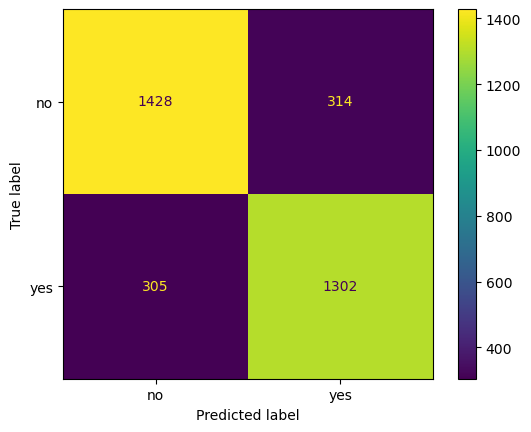

In [26]:
# Test prediction
y_pred_final = final_model.predict(x_test)

# Detailed metrics
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
print('Classification Report:\n', classification_report(y_test, y_pred_final), '%')

In [27]:
# Parameter for the grid using entropy, log_loss, including splitter
params = {'max_depth': list(range(6,13)),
          'min_samples_split': list(range(2,9,2)),
          'min_samples_leaf': list(range(1,5)),
          'criterion' : ['gini', 'entropy', 'log_loss'],
          'splitter' : ['best']}

# estimator - classifier
dt = DecisionTreeClassifier(random_state = 42)

# setup the grid search
grid_search = GridSearchCV(estimator = dt,
                           param_grid = params,
                           cv = 5,
                           n_jobs = -1,
                           verbose = 4)

# fit the gridsearch model to the data
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 336 candidates, totalling 1680 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [6, 7, 8, 9, 10, 11, 12],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 4, 6, 8],
                         'splitter': ['best']},
             verbose=4)

In [28]:
# Building the final model with best parameters
best_params = grid_search.best_params_
final_model = DecisionTreeClassifier(**best_params, random_state = 42)

# Fit the data onto the model
final_model.fit(x_train, y_train)
print('Training Score:', round(final_model.score(x_train, y_train)*100, 2), '%')

Training Score: 84.68 %


Classification Report:
               precision    recall  f1-score   support

          no       0.82      0.82      0.82      1742
         yes       0.81      0.81      0.81      1607

    accuracy                           0.82      3349
   macro avg       0.81      0.81      0.81      3349
weighted avg       0.82      0.82      0.82      3349
 %


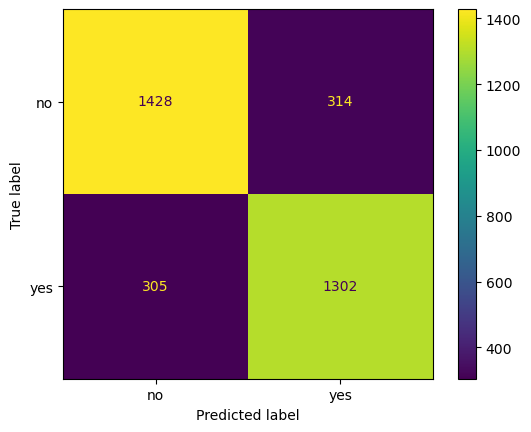

In [29]:
# Test prediction
y_pred_final = final_model.predict(x_test)

# Detailed metrics
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
print('Classification Report:\n', classification_report(y_test, y_pred_final), '%')

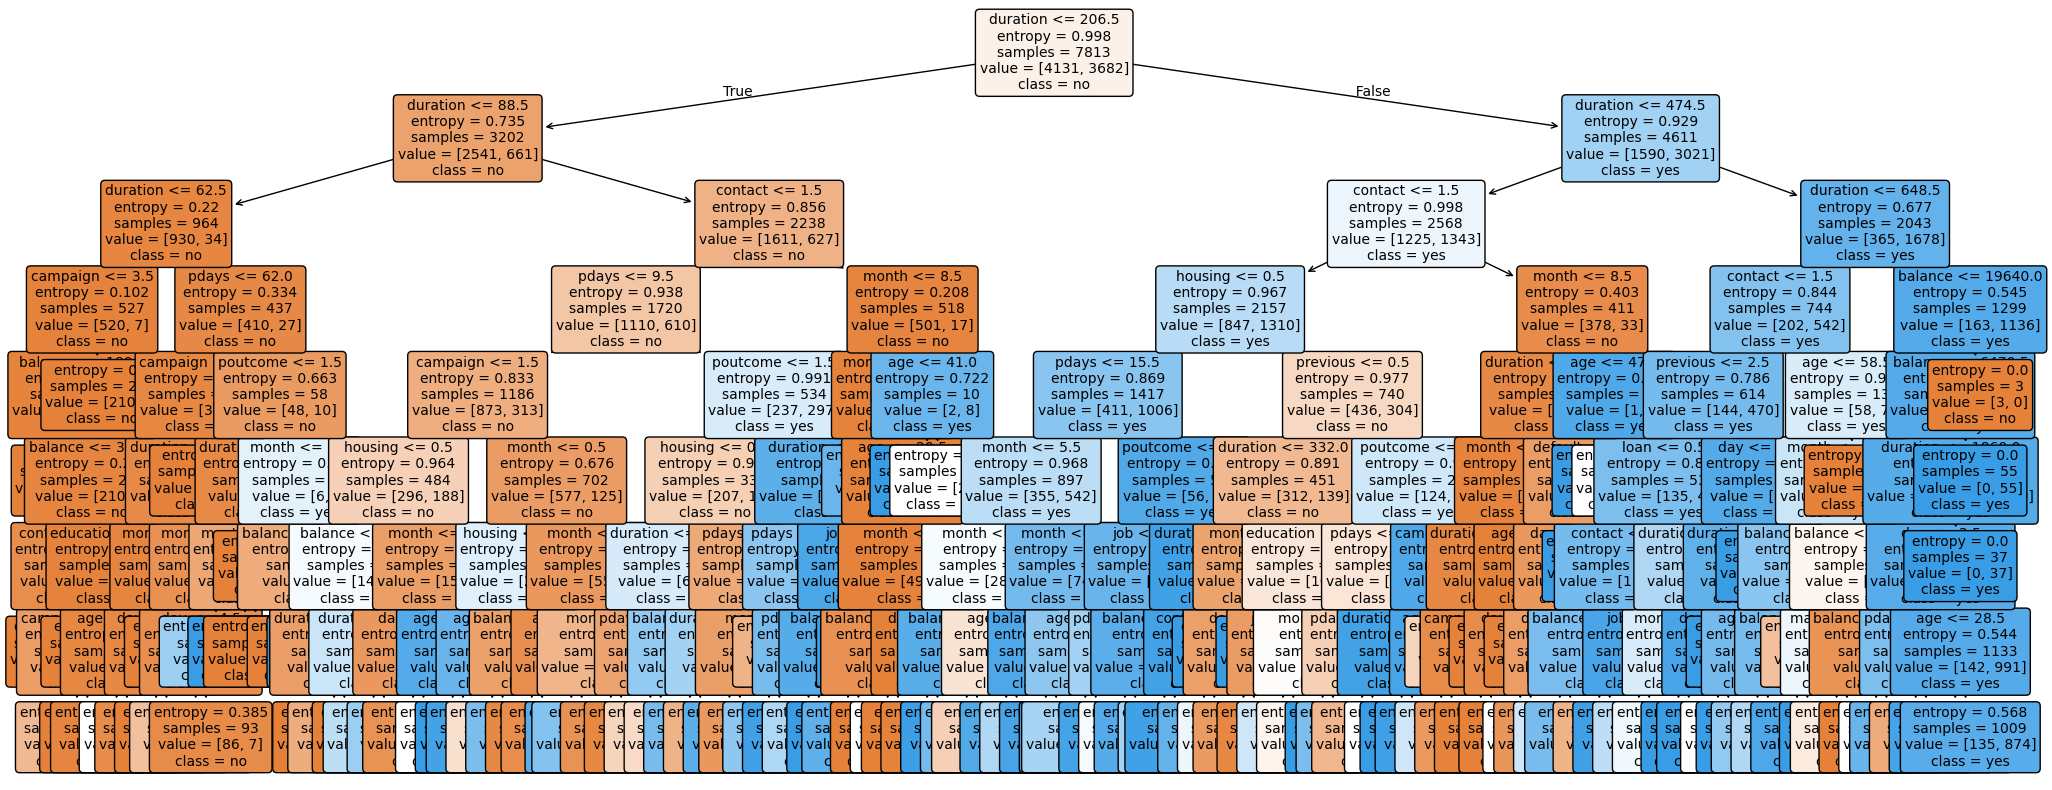

In [30]:
from sklearn.tree import plot_tree

feature_names = x.columns.tolist()
class_names = [str(c) for c in final_model.classes_]

plt.figure(figsize=(25, 10))
plot_tree(
    final_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()